In [1]:
import torch
from torch.utils.data import Dataset

In [2]:
class MyDataSet(Dataset):
    def __init__(self, size = 100):
        self.x = torch.randn(size, 3)
        self.y = torch.randint(0, 2, (size, )).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [3]:
dataset = MyDataSet(size= 100)

In [4]:
dataset

In [5]:
print(len(dataset))

100


In [6]:
x, y = dataset[0]

print(x.shape)

torch.Size([3])


In [7]:
x

tensor([-0.0672, -0.7193, -0.6210])

In [8]:
y

tensor(0.)

In [9]:
import os
from PIL import Image
from torchvision import transforms

In [11]:
class ImageDataset(Dataset):
    def __init__(self, img_dir, transform = None):
        self.img_paths = [
            os.path.join(img_dir, f)
            for f in os.listdir(img_dir)
            if f.endswith(('.jpg', '.png'))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx])
        if self.transform:
            img = self.transform(img)
        return img

In [12]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [13]:
dataset = ImageDataset("./data/images", transform=transform)

In [14]:
print(len(dataset))

3


In [19]:
img_tensor = dataset[0]
img_tensor.shape

torch.Size([3, 224, 224])

In [20]:
print("数据范围:", img_tensor.min().item(), "~", img_tensor.max().item())

数据范围: 0.33725491166114807 ~ 1.0


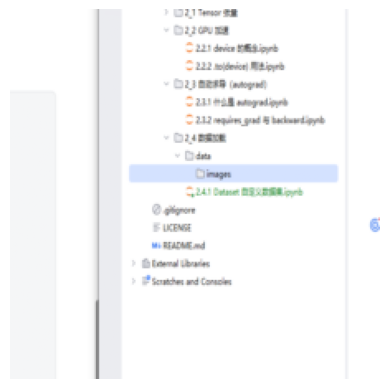

In [23]:
import matplotlib.pyplot as plt

img_tensor = dataset[0]

plt.imshow(img_tensor.permute(1, 2, 0))
plt.axis("off")
plt.show()

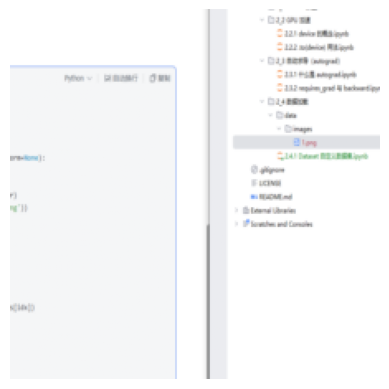

In [24]:
import matplotlib.pyplot as plt

img_tensor = dataset[1]

plt.imshow(img_tensor.permute(1, 2, 0))
plt.axis("off")
plt.show()

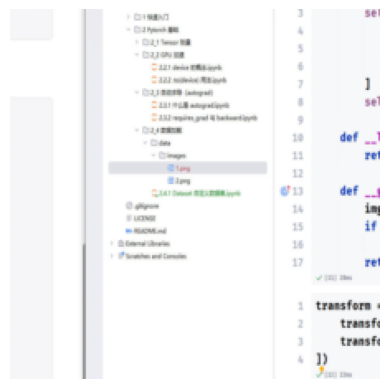

In [25]:
import matplotlib.pyplot as plt

img_tensor = dataset[2]

plt.imshow(img_tensor.permute(1, 2, 0))
plt.axis("off")
plt.show()